In [4]:
import os
from urllib.parse import urlencode

import geopandas as gpd
import requests
from shapely.geometry import Polygon

Skorowidze NMT w usłudze WMS/WFS: https://www.geoportal.gov.pl/pl/dane/numeryczny-model-terenu-nmt/  

Dane Usługi powbierania WFS: https://www.geoportal.gov.pl/pl/usluga/uslugi-pobierania-wfs/

Żeby znać wszystkie parametry trzeba trochę pogrzebać w skorowidzach. 

In [5]:
# --- USER INPUT ---
AOI_PATH = "./03_dane/aoi_krakow_1.gpkg"  # or .shp
WFS_URL = "https://mapy.geoportal.gov.pl/wss/service/PZGIK/NumerycznyModelTerenuEVRF2007/WFS/Skorowidze"  # example – adjust to real DSM WFS URL you copied
LAYER_NAME = "gugik:SkorowidzNMT2021"  # adjust to actual featureType name
OUT_DIR = "./03_dane"

os.makedirs(OUT_DIR, exist_ok=True)

In [6]:
# Wczytanie AOI (najlepiej w EPSG:2180)
aoi = gpd.read_file(AOI_PATH)

geom = aoi.union_all()  # jeśli kilka geometrii
coords = list(geom.envelope.exterior.coords)  # prostokąt otaczający

# zamiana x<->y
swapped = [(y, x) for x, y in coords]
poly_swapped = Polygon(swapped)

minx, miny, maxx, maxy = poly_swapped.bounds

# Definicja parametrów WFS
params = dict(
    service="WFS",
    version="2.0.0",
    request="GetFeature",
    typeNames=LAYER_NAME,
    bbox=f"{minx},{miny},{maxx},{maxy},EPSG:2180",
    # outputFormat="application/json"
)

url = f"{WFS_URL}?{urlencode(params)}"

# Wczytanie GML bezpośrednio do GeoPandas
gdf = gpd.read_file(url)
print("Liczba kafli:", len(gdf))
print(gdf.crs)
print("Kolumny:", gdf.columns)
display(gdf)

gdf.to_csv(os.path.join(OUT_DIR, 'skorowidz_kafli_2021.csv'))
# na tym etapie utworzono skorowidz kafli który może być uznany jako 
# baza danych GeoDataFrame. W nim są linki do pobrania poszczególnych kafli NMT. 


Liczba kafli: 6
EPSG:2180
Kolumny: Index(['gml_id', 'lowerCorner', 'upperCorner', 'godlo', 'akt_rok',
       'asortyment', 'format', 'char_przestrz', 'blad_sr_wys', 'uklad_xy',
       'modul_archiwizacji', 'uklad_h', 'nr_zglosz', 'timePosition',
       'czy_ark_wypelniony', 'url_do_pobrania', 'zrodlo_danych',
       'dt_pzgik|timePosition', 'blad_sr_syt', 'geometry'],
      dtype='str')


,gml_id,lowerCorner,upperCorner,godlo,akt_rok,asortyment,format,char_przestrz,blad_sr_wys,uklad_xy,modul_archiwizacji,uklad_h,nr_zglosz,timePosition,czy_ark_wypelniony,url_do_pobrania,zrodlo_danych,dt_pzgik|timePosition,blad_sr_syt,geometry
0,SkorowidzNMT2021.1140202,242320.533949 563179.745561,243362.310306 564804.873459,7.125.11.16,2021,NMT,ARC/INFO ASCII GRID,1.00 m,0.1,PL-2000:S7,1:2000,PL-EVRF2007-NH,DFT.7201.036.2021,2021-10-05,TAK,https://opendata.geoportal.gov.pl/NumDaneWys/N...,Skaning laserowy,2022-06-03,0.25,"POLYGON ((563179.746 243319.524, 564778.133 24..."
1,SkorowidzNMT2021.1140265,241321.544136 563206.485371,242363.315009 564831.609973,7.125.11.21,2021,NMT,ARC/INFO ASCII GRID,1.00 m,0.1,PL-2000:S7,1:2000,PL-EVRF2007-NH,DFT.7201.036.2021,2021-10-05,TAK,https://opendata.geoportal.gov.pl/NumDaneWys/N...,Skaning laserowy,2022-06-03,0.25,"POLYGON ((563206.485 242320.534, 564804.873 24..."
2,SkorowidzNMT2021.1140328,240322.554187 563233.221668,241364.319575 564858.342975,7.124.11.01,2021,NMT,ARC/INFO ASCII GRID,1.00 m,0.1,PL-2000:S7,1:2000,PL-EVRF2007-NH,DFT.7201.036.2021,2021-10-05,TAK,https://opendata.geoportal.gov.pl/NumDaneWys/N...,Skaning laserowy,2022-06-03,0.25,"POLYGON ((563233.222 241321.544, 564831.61 241..."
3,SkorowidzNMT2021.1140205,242363.315009 564778.133432,243405.097334 566403.270538,7.125.11.17,2021,NMT,ARC/INFO ASCII GRID,1.00 m,0.1,PL-2000:S7,1:2000,PL-EVRF2007-NH,DFT.7201.036.2021,2021-10-05,TAK,https://opendata.geoportal.gov.pl/NumDaneWys/N...,Skaning laserowy,2022-06-03,0.25,"POLYGON ((564778.133 243362.31, 566376.53 2434..."
4,SkorowidzNMT2021.1140268,241364.319575 564804.873459,242406.096418 566430.007272,7.125.11.22,2021,NMT,ARC/INFO ASCII GRID,1.00 m,0.1,PL-2000:S7,1:2000,PL-EVRF2007-NH,DFT.7201.036.2021,2021-10-05,TAK,https://opendata.geoportal.gov.pl/NumDaneWys/N...,Skaning laserowy,2022-06-03,0.25,"POLYGON ((564804.873 242363.315, 566403.271 24..."
5,SkorowidzNMT2021.1140331,240365.324005 564831.609973,241407.095364 566456.740493,7.124.11.02,2021,NMT,ARC/INFO ASCII GRID,1.00 m,0.1,PL-2000:S7,1:2000,PL-EVRF2007-NH,DFT.7201.036.2021,2021-10-05,TAK,https://opendata.geoportal.gov.pl/NumDaneWys/N...,Skaning laserowy,2022-06-03,0.25,"POLYGON ((564831.61 241364.32, 566430.007 2414..."


In [7]:
os.makedirs(OUT_DIR, exist_ok=True)

LINK_FIELD = "url_do_pobrania"

for idx, row in gdf.iterrows():
    link = row.get(LINK_FIELD)
    if not isinstance(link, str) or not link:
        continue

    fname = os.path.basename(link.split("?")[0])
    out_path = os.path.join(OUT_DIR, fname)

    if os.path.exists(out_path):
        print("Istnieje, pomijam:", out_path)
        continue

    print("Pobieram:", out_path)
    resp = requests.get(link, stream=True)
    resp.raise_for_status()
    with open(out_path, "wb") as f:
        for chunk in resp.iter_content(chunk_size=8192):
            if chunk:
                f.write(chunk)

Pobieram: ./03_dane/75172_1140202_7.125.11.16.asc
Pobieram: ./03_dane/75172_1140265_7.125.11.21.asc
Pobieram: ./03_dane/75172_1140328_7.124.11.01.asc
Pobieram: ./03_dane/75172_1140205_7.125.11.17.asc
Pobieram: ./03_dane/75172_1140268_7.125.11.22.asc
Pobieram: ./03_dane/75172_1140331_7.124.11.02.asc


Zadanie

1. Wczytaj obszar aoi za pomocą np BBOX zbudowanego dla gminy jak w poprzednich ćwiczeniach (uwaga będzie bardzo duzo kafli!!! - lepiej nie pobierać tylko zrobić sam skorowidz)  

2. Zredaguj skrypt tak aby pobierać np granic gmin lub powiatów lub inne dane wektorowe z geoportalu. 
Dane Usługi powbierania WFS: https://www.geoportal.gov.pl/pl/usluga/uslugi-pobierania-wfs/

In [11]:
path_gminy_krk = "./02_dane/gminy_powiat_krakowski.gml"
gminy = gpd.read_file(path_gminy_krk)
wybrana_gmina = "Liszki"
gmina_sel = gminy[gminy["JPT_NAZWA__1"] == wybrana_gmina]

bbox_gmina_2180 = gmina_sel.total_bounds
bbox_gmina_2180

array([547299.52, 234877.14, 559369.2 , 247571.07])

In [12]:
WFS_URL = "https://mapy.geoportal.gov.pl/wss/service/PZGIK/NumerycznyModelPokryciaTerenuEVRF2007/WFS/Skorowidze"
LAYER_NAME = "gugik:SkorowidzNMPT2025"
OUT_DIR = "./03_dane"

params = dict(
    service="WFS",
    version="2.0.0",
    request="GetFeature",
    typeNames=LAYER_NAME,
    bbox=f"{bbox_gmina_2180[1]},{bbox_gmina_2180[0]},{bbox_gmina_2180[3]},{bbox_gmina_2180[2]},EPSG:2180",
    # outputFormat="application/json"
)

url = f"{WFS_URL}?{urlencode(params)}"

# Wczytanie GML bezpośrednio do GeoPandas
gdf = gpd.read_file(url)
print("Liczba kafli:", len(gdf))
print(gdf.crs)
print("Kolumny:", gdf.columns)
display(gdf)

gdf.to_csv(os.path.join(OUT_DIR, 'skorowidz_kafli_nmpt_2025.csv'))

Liczba kafli: 11
EPSG:2180
Kolumny: Index(['gml_id', 'lowerCorner', 'upperCorner', 'godlo', 'akt_rok',
       'asortyment', 'format', 'char_przestrz', 'blad_sr_wys', 'uklad_xy',
       'modul_archiwizacji', 'uklad_h', 'nr_zglosz', 'timePosition',
       'czy_ark_wypelniony', 'url_do_pobrania', 'zrodlo_danych',
       'dt_pzgik|timePosition', 'blad_sr_syt', 'geometry'],
      dtype='str')


,gml_id,lowerCorner,upperCorner,godlo,akt_rok,asortyment,format,char_przestrz,blad_sr_wys,uklad_xy,modul_archiwizacji,uklad_h,nr_zglosz,timePosition,czy_ark_wypelniony,url_do_pobrania,zrodlo_danych,dt_pzgik|timePosition,blad_sr_syt,geometry
0,SkorowidzNMPT2025.1729449,241915.800000 558136.180000,244256.290000 560398.310000,M-34-64-D-c-2-3,2025,NMPT,ARC/INFO ASCII GRID,0.50 m,0.15,PL-1992,1:5000,PL-EVRF2007-NH,GK-FOTO.6201.5.2025,2025-04-28,TAK,https://opendata.geoportal.gov.pl/NumDaneWys/N...,Skaning laserowy,2025-11-07,0.15,"POLYGON ((558142.48 243652.53, 558136.18 24423..."
1,SkorowidzNMPT2025.1729452,237260.780000 555948.610000,239600.320000 558211.690000,M-34-64-D-c-3-4,2025,NMPT,ARC/INFO ASCII GRID,0.50 m,0.15,PL-1992,1:5000,PL-EVRF2007-NH,GK-FOTO.6201.5.2025,2025-04-28,TAK,https://opendata.geoportal.gov.pl/NumDaneWys/N...,Skaning laserowy,2025-11-07,0.15,"POLYGON ((555954.66 238997.5, 555948.61 239576..."
2,SkorowidzNMPT2025.1729455,237284.640000 558186.530000,239625.110000 560450.570000,M-34-64-D-c-4-3,2025,NMPT,ARC/INFO ASCII GRID,0.50 m,0.15,PL-1992,1:5000,PL-EVRF2007-NH,GK-FOTO.6201.5.2025,2025-04-28,TAK,https://opendata.geoportal.gov.pl/NumDaneWys/N...,Skaning laserowy,2025-11-07,0.15,"POLYGON ((558192.82 239021.35, 558186.53 23960..."
3,SkorowidzNMPT2025.1729453,239600.320000 558161.360000,241940.590000 560424.440000,M-34-64-D-c-4-1,2025,NMPT,ARC/INFO ASCII GRID,0.50 m,0.15,PL-1992,1:5000,PL-EVRF2007-NH,GK-FOTO.6201.5.2025,2025-04-28,TAK,https://opendata.geoportal.gov.pl/NumDaneWys/N...,Skaning laserowy,2025-11-07,0.15,"POLYGON ((558167.65 241337.04, 558161.36 24191..."
4,SkorowidzNMPT2025.1729509,234945.100000 555972.800000,237284.640000 558236.840000,M-34-76-B-a-1-2,2025,NMPT,ARC/INFO ASCII GRID,0.50 m,0.15,PL-1992,1:5000,PL-EVRF2007-NH,GK-FOTO.6201.5.2025,2025-04-28,TAK,https://opendata.geoportal.gov.pl/NumDaneWys/N...,Skaning laserowy,2025-11-07,0.15,"POLYGON ((555978.85 236681.81, 555972.8 237260..."
5,SkorowidzNMPT2025.1729445,244207.660000 555875.980000,246547.210000 558136.180000,M-34-64-D-c-1-2,2025,NMPT,ARC/INFO ASCII GRID,0.50 m,0.15,PL-1992,1:5000,PL-EVRF2007-NH,GK-FOTO.6201.5.2025,2025-04-28,TAK,https://opendata.geoportal.gov.pl/NumDaneWys/N...,Skaning laserowy,2025-11-07,0.15,"POLYGON ((555882.04 245944.39, 555875.98 24652..."
6,SkorowidzNMPT2025.1729451,239576.470000 555924.410000,241915.800000 558186.530000,M-34-64-D-c-3-2,2025,NMPT,ARC/INFO ASCII GRID,0.50 m,0.15,PL-1992,1:5000,PL-EVRF2007-NH,GK-FOTO.6201.5.2025,2025-04-28,TAK,https://opendata.geoportal.gov.pl/NumDaneWys/N...,Skaning laserowy,2025-11-07,0.15,"POLYGON ((555930.46 241313.19, 555924.41 24189..."
7,SkorowidzNMPT2025.1729447,244231.510000 558111.000000,246571.990000 560372.160000,M-34-64-D-c-2-1,2025,NMPT,ARC/INFO ASCII GRID,0.50 m,0.15,PL-1992,1:5000,PL-EVRF2007-NH,GK-FOTO.6201.5.2025,2025-04-28,TAK,https://opendata.geoportal.gov.pl/NumDaneWys/N...,Skaning laserowy,2025-11-07,0.15,"POLYGON ((558117.29 245968.23, 558111 246547.2..."
8,SkorowidzNMPT2025.1729446,241891.960000 555900.200000,244231.510000 558161.360000,M-34-64-D-c-1-4,2025,NMPT,ARC/INFO ASCII GRID,0.50 m,0.15,PL-1992,1:5000,PL-EVRF2007-NH,GK-FOTO.6201.5.2025,2025-04-28,TAK,https://opendata.geoportal.gov.pl/NumDaneWys/N...,Skaning laserowy,2025-11-07,0.15,"POLYGON ((555906.25 243628.68, 555900.2 244207..."
9,SkorowidzNMPT2025.1729434,246547.210000 558085.810000,248887.490000 560346.010000,M-34-64-D-a-4-3,2025,NMPT,ARC/INFO ASCII GRID,0.50 m,0.15,PL-1992,1:5000,PL-EVRF2007-NH,GK-FOTO.6201.5.2025,2025-04-28,TAK,https://opendata.geoportal.gov.pl/NumDaneWys/N...,Skaning laserowy,2025-11-07,0.15,"POLYGON ((558092.1 248283.95, 558085.81 248862..."


In [ ]:
# pobieranie kafli 11 x 150MB

# os.makedirs(OUT_DIR, exist_ok=True)
#
# LINK_FIELD = "url_do_pobrania"
#
# for idx, row in gdf.iterrows():
#     link = row.get(LINK_FIELD)
#     if not isinstance(link, str) or not link:
#         continue
#
#     fname = os.path.basename(link.split("?")[0])
#     out_path = os.path.join(OUT_DIR, fname)
#
#     if os.path.exists(out_path):
#         print("Istnieje, pomijam:", out_path)
#         continue
#
#     print("Pobieram:", out_path)
#     resp = requests.get(link, stream=True)
#     resp.raise_for_status()
#     with open(out_path, "wb") as f:
#         for chunk in resp.iter_content(chunk_size=8192):
#             if chunk:
#                 f.write(chunk)

In [15]:
WFS_URL = "https://mapy.geoportal.gov.pl/wss/ext/KrajowaIntegracjaNumeracjiAdresowej"
LAYER_NAME = "ms:prg-adresy"
OUT_DIR = "./03_dane"

params = dict(
    service="WFS",
    version="2.0.0",
    request="GetFeature",
    typeNames=LAYER_NAME,
    bbox=f"{bbox_gmina_2180[1]},{bbox_gmina_2180[0]},{bbox_gmina_2180[3]},{bbox_gmina_2180[2]},EPSG:2180",
    # outputFormat="application/json"
)

url = f"{WFS_URL}?{urlencode(params)}"

# Wczytanie GML bezpośrednio do GeoPandas
gdf = gpd.read_file(url)
print("Liczba adresów:", len(gdf))
print(gdf.crs)
print("Kolumny:", gdf.columns)
display(gdf)

gdf.to_csv(os.path.join(OUT_DIR, 'adresy.csv'))

Liczba adresów: 15837
EPSG:2180
Kolumny: Index(['gml_id', 'miejscowosc', 'ulica', 'numer', 'teryt', 'simc', 'ulic',
       'kod', 'geometry'],
      dtype='str')


,gml_id,miejscowosc,ulica,numer,teryt,simc,ulic,kod,geometry
0,prg-adresy.3151835,Mników,Gaik,3,120607,0325529,05242,32-084,POINT (550989.63 244222.469)
1,prg-adresy.3151836,Mników,Gaik,1,120607,0325529,05242,32-084,POINT (550906.592 244165.73)
2,prg-adresy.2455447,Liszki,Poległych 1943 roku,16,120607,0325452,58406,32-060,POINT (555091.15 241874.531)
3,prg-adresy.2456567,Liszki,Poległych 1943 roku,17,120607,0325452,58406,32-060,POINT (555024.178 241947.21)
4,prg-adresy.2456355,Liszki,Poległych 1943 roku,9,120607,0325452,58406,32-060,POINT (555057.646 241785.187)
...,...,...,...,...,...,...,...,...,...
15832,prg-adresy.2544478,Brzoskwinia,NaN,158B,120616,0343674,NaN,32-084,POINT (552261.054 246514.198)
15833,prg-adresy.2543866,Brzoskwinia,NaN,158,120616,0343674,NaN,32-084,POINT (552270.031 246470.513)
15834,prg-adresy.2444612,Wołowice,NaN,10,120601,0316281,NaN,32-070,POINT (554174.77 235803.495)
15835,prg-adresy.2452793,Dąbrowa Szlachecka,NaN,148,120601,0315672,NaN,32-070,POINT (551438.833 238890.719)


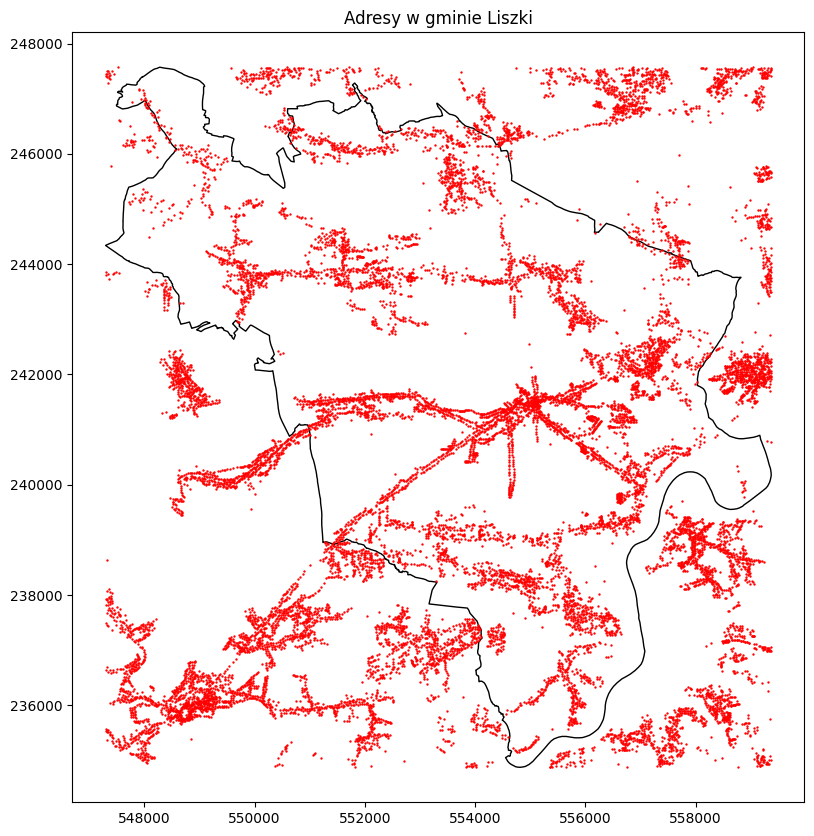

In [30]:
from matplotlib import pyplot as plt

fig, ax = plt.subplots(figsize=(10, 10))
gmina_sel.plot(ax=ax, facecolor="none", edgecolor="black")
gdf.plot(ax=ax, color="red", markersize=0.5)
ax.set_title(f"Adresy w gminie {wybrana_gmina}")
plt.show()